# **Week 3 | Actividad 2: Implementación de Backpropagation y Funciones de Activación en Redes Neuronales en Google Colab**


En esta actividad, las y los creadores de oportunidades implementarán y validarán el proceso de aprendizaje de una red neuronal mediante backpropagation y el uso de funciones de activación, en un entorno de práctica guiada (Google Colab). El propósito es evidenciar cómo una red ajusta sus parámetros (pesos y sesgos) para reducir el error durante el entrenamiento, y cómo las funciones de activación influyen en el comportamiento del modelo y su capacidad de aprendizaje.

La actividad se orienta a consolidar criterios básicos de entrenamiento: cálculo de salida, pérdida (loss), actualización de parámetros y seguimiento del desempeño mediante métricas. La evidencia debe mostrar resultados verificables y conclusiones breves sustentadas en la observación.

# 1. Producto a entregar
> - Un notebook ejecutable (.ipynb) desarrollado en Google Colab, con evidencia organizada en GitHub.

# 2. Características mínimas del notebook (obligatorias)
El notebook debe:

> - Incluir una red neuronal básica entrenable (no solo inferencia), donde sea visible el proceso de ajuste de parámetros (backpropagation).

> - Incluir funciones de activación y evidencia comparativa de al menos dos activaciones (por ejemplo: sigmoid y ReLU), manteniendo constantes los demás elementos para que la comparación sea válida.

> - Mostrar el comportamiento del entrenamiento a lo largo de iteraciones/épocas (por ejemplo: evolución del loss y/o una métrica de desempeño).

> - Reportar al menos una métrica de evaluación y evidencia verificable de resultados (impresiones, tabla o gráfico).

> - Incluir análisis escrito (Markdown) con conclusiones breves sobre: (i) qué cambió al variar la activación, (ii) cómo se comportó el loss/métrica, (iii) principales dificultades o hallazgos.



# 3. Evidencia en GitHub (obligatoria)
> - Carpeta de la semana: week3/

> - Archivo principal: notebook .ipynb

> - Archivo de soporte: README.md breve con: objetivo, qué se implementó, qué activaciones se compararon, resultados principales (1–2 líneas) y cómo ejecutar el notebook.

# 4. Condiciones de calidad (criterio de aceptación)
> - El notebook ejecuta de principio a fin sin errores.

> - Los resultados son reproducibles y verificables (no solo capturas).

> - La comparación de activaciones es coherente (mismo dataset y configuración base; solo cambia la activación).

> - El repositorio permite identificar con claridad la evidencia de Semana 3 (estructura y nombres).

# 5) Forma de entrega
> - Entregar el enlace directo a la carpeta week3/ del repositorio de GitHub.

# **Desarollo| Actividad 2: Implementación de Backpropagation y Funciones de Activación en Redes Neuronales en Google Colab**

# Red neuronal básica  y aprendizaje con backpropagation

> **Objetivo:** Implementar y validar una red neuronal básica entrenable para entender:
> - Qué hace una neurona/perceptrón
> - Cómo se calcula el puntaje Z
> - Qué es una función de activación
> - Y cómo ocurre el aprendizaje (ajuste de pesos) mediante backpropagation

---

## Conceptos básicos (explicación para principiantes)

### ¿Qué es una red neuronal?

Una red neuronal artificial (RNA) es un modelo computacional inspirado en el funcionamiento de la neurona biológica.  
Está compuesta por neuronas artificiales interconectadas que aprenden a partir de ejemplos.


- **Capa de entrada:** recibe las variables de entrada.
- **Capa oculta:** transforma las entradas aplicando *pesos*, *sesgo* y una *función no lineal*.
- **Capa de salida:** produce el resultado final (en este caso, una probabilidad entre 0 y 1).

### ¿Qué son entradas, pesos y sesgo (bias)?

- **Entradas (x):** valores que representan la información del problema.
- **Pesos (w):** indican la importancia de cada entrada.
- **Bias (b):** permite desplazar la función de activación.


Una neurona recibe entradas (X).Cada entrada tiene asociado un peso (W) que indica su importancia. Además existe un bias (b) que permite ajustar el resultado.

La operación básica es:

\[
  z = (X · W) + b
\]
### ¿Qué es el puntaje z?
Una neurona primero calcula:

\[
z = w\cdot x + b
\]

Ese **z** es el “puntaje” antes de aplicar la activación.


### ¿Qué es una función de activación?
Convierte `z` en una salida activada `a`:

\[
a = f(z)
\]

Agrega **no linealidad** (sin activación, muchas capas serían equivalente a una sola operación lineal).

En este notebook compararemos:
- **Sigmoid**: produce valores entre 0 y 1.
- **ReLU**: `ReLU(z) = max(0, z)`.

### ¿Qué es el entrenamiento con backpropagation?
Entrenar significa ajustar pesos para que la predicción se acerque a la etiqueta real.

1. **Forward pass:** calculamos predicciones.
2. **Loss:** medimos el error.
3. **Backpropagation:** calculamos gradientes del error respecto a los pesos.
4. **Update:** actualizamos pesos para reducir el error.

En TensorFlow esto se hace con autodiferenciación usando `tf.GradientTape`.


El entrenamiento es **supervisado**:
- La red compara su salida con la salida deseada
- Calcula el error
- Ajusta los pesos usando **backpropagation**
- El error se propaga desde la salida hacia atrás

Este proceso se repite durante varias épocas.



**Dataset sencillo (clasificación binaria)**

Usamos el ejemplo clásico del libro "Una aproximacion practica": función lógica OR


El siguiente codigo se encarga definir los patrones de entrenamiento y sus salidas deseadas para un aprendizaje supervisado


> - Prepara las entradas
> - Define las salidas correctas
> - Organiza los datos para que la red pueda aprender




In [ ]:
import numpy as np
import pandas as pd

# Entradas
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# Salidas (OR)
y = np.array([
    [0],
    [1],
    [1],
    [1]
], dtype=np.float32)

pd.DataFrame(np.hstack((X, y)), columns=["x1", "x2", "salida"])

,x1,x2,salida
0,0.0,0.0,0.0
1,0.0,1.0,1.0
2,1.0,0.0,1.0
3,1.0,1.0,1.0


Este bloque de código importa las librerías necesarias para construir una red neuronal tipo perceptrón multicapa, entrenarla mediante backpropagation y visualizar su comportamiento durante el aprendizaje.

ensorflowMotor para redes neuronales

SequentialTipo de red: una capa después de otra

DenseCapas con neuronas conectadas

matplotlibDibujar gráficos

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

Esta función crea una red neuronal tipo perceptrón multicapa, define su arquitectura, especifica cómo aprenderá mediante backpropagation y la deja lista para ser entrenada.

In [ ]:


def crear_modelo(activacion_oculta):
    model = Sequential([
        Dense(4, activation=activacion_oculta, input_shape=(2,)),  # Capa oculta
        Dense(1, activation='sigmoid')  # Capa de salida binaria
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


Este código crea una red neuronal con función Sigmoid en la capa oculta y la entrena usando aprendizaje supervisado durante 100 épocas, ajustando los pesos mediante backpropagation.

In [ ]:

modelo_sigmoid = crear_modelo('sigmoid')

hist_sigmoid = modelo_sigmoid.fit(
    X, y,
    epochs=100,
    verbose=0
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Este bloque de código grafica la evolución del error (loss) y la precisión (accuracy) durante el entrenamiento de la red neuronal con función Sigmoid, permitiendo visualizar el proceso de aprendizaje.

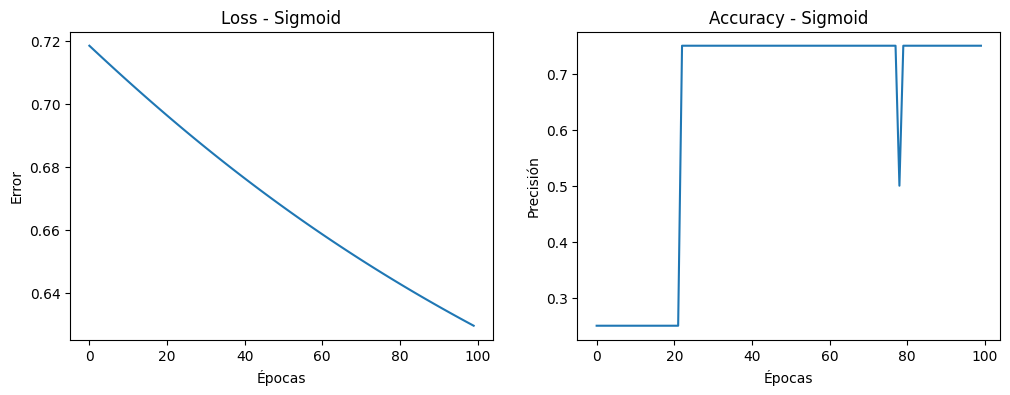

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist_sigmoid.history['loss'])
plt.title("Loss - Sigmoid")
plt.xlabel("Épocas")
plt.ylabel("Error")

plt.subplot(1,2,2)
plt.plot(hist_sigmoid.history['accuracy'])
plt.title("Accuracy - Sigmoid")
plt.xlabel("Épocas")
plt.ylabel("Precisión")

plt.show()


Este bloque de código crea y entrena una red neuronal con función de activación ReLU en la capa oculta, utilizando aprendizaje supervisado durante 100 épocas, permitiendo comparar su desempeño con una red que usa Sigmoid.

In [ ]:

modelo_relu = crear_modelo('relu')

hist_relu = modelo_relu.fit(
    X, y,
    epochs=100,
    verbose=0
)


Este bloque de código grafica la evolución del error y la precisión durante el entrenamiento de la red neuronal con función de activación ReLU, permitiendo comparar su comportamiento con el modelo que utiliza Sigmoid.

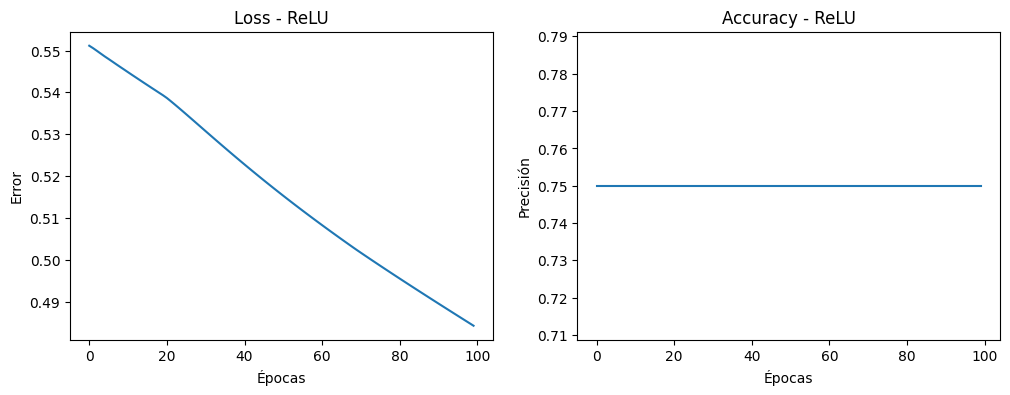

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(hist_relu.history['loss'])
plt.title("Loss - ReLU")
plt.xlabel("Épocas")
plt.ylabel("Error")

plt.subplot(1,2,2)
plt.plot(hist_relu.history['accuracy'])
plt.title("Accuracy - ReLU")
plt.xlabel("Épocas")
plt.ylabel("Precisión")

plt.show()

Este bloque de código evalúa el desempeño final de las redes neuronales entrenadas con funciones de activación Sigmoid y ReLU, obteniendo el error y la precisión, y presenta los resultados en una tabla comparativa.

In [ ]:

loss_s, acc_s = modelo_sigmoid.evaluate(X, y, verbose=0)
loss_r, acc_r = modelo_relu.evaluate(X, y, verbose=0)

resultados = pd.DataFrame({
    "Activación": ["Sigmoid", "ReLU"],
    "Loss Final": [loss_s, loss_r],
    "Accuracy Final": [acc_s, acc_r]
})

resultados


,Activación,Loss Final,Accuracy Final
0,Sigmoid,0.629034,0.75
1,ReLU,0.483640,0.75


Este bloque de código muestra las predicciones finales de las redes neuronales entrenadas con Sigmoid y ReLU, permitiendo verificar que ambas aprendieron correctamente la función lógica OR

In [ ]:

print("Predicciones Sigmoid:")
print(np.round(modelo_sigmoid.predict(X),2))

print("\nPredicciones ReLU:")
print(np.round(modelo_relu.predict(X),2))


Predicciones Sigmoid:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
[[0.52]
 [0.52]
 [0.57]
 [0.57]]

Predicciones ReLU:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[[0.53]
 [0.52]
 [0.84]
 [0.7 ]]



## Análisis

### ¿Qué cambió al usar diferentes funciones de activación?
- La activación cambia cómo se transforma `z` y, por tanto, los gradientes y el aprendizaje.
- **Sigmoid** puede saturarse (gradientes pequeños) y entrenar más lento.
- **ReLU** suele converger más rápido, pero puede sufrir “neuronas muertas” si quedan siempre en 0.

### ¿Cómo se comportó el loss?
- Ideal: el **loss baja** con las épocas.
- Si se estanca: revisar tasa de aprendizaje, activación o tamaño de la capa oculta.

### ¿Cuál activación funcionó mejor?
- Revisa accuracy final y curvas de loss/accuracy.

### Dificultades típicas
- Probabilidad (0-1) vs clase (0/1). Para clase, usamos umbral 0.5.
- Learning rate muy alto (inestable) o muy bajo (lento).



---

## Conclusión

En esta actividad se implementó una red neuronal básica entrenada mediante backpropagation para un problema de clasificación binaria. Al comparar las funciones de activación, se observó que ambas permitieron el aprendizaje del patrón general, aunque ReLU mostró una reducción más rápida del error. Sin embargo, la accuracy final del 75% evidencia que la arquitectura y los hiperparámetros podrían optimizarse para lograr una mejor separación de clases. Este ejercicio permitió comprender de manera práctica el rol de las funciones de activación en el proceso de aprendizaje.